# 1c. Model vs Real Data Comparison (BE & SC)

**Purpose**: Do the BE and SC models' predicted learning trajectories match
real animals? Putting synthetic and real data on the same axes for both models.

**Sections**:
1. Generate synthetic trajectories (BE and SC, multiple animals)
2. Load real data
3. Stat trajectory overlay (BE vs SC vs real)
4. Update matrix comparison at matched phases
5. Expert-phase stat distributions


## 1. Configuration & Imports

In [7]:
from shared_setup import *

from models.BE_core import BEParams, BEState, BEModel
from models.SC_core import SCParams, SCState, SCModel
from models.perception import perceive_stimulus
from behav_utils.plotting.styles import COLOURS, apply_style

apply_style()

In [8]:
# ── Config ──────────────────────────────────────────────────────────────────
CONFIG_PATH = PATH_CONFIG
STAGE = 'Full_Task_Cont'
MIN_SESSIONS = 15

N_SYNTHETIC = 5
N_SESSIONS_SYN = 30
TRIALS_PER_SESSION = 350
BURN_IN = 1000

COMPARE_STATS = [
    'accuracy', 'psychometric_gof',
    'pse', 'slope', 'lapse_low', 'lapse_high',
    'recency', 'win_stay_rate', 'stimulus_sensitivity',
    'choice_entropy', 'perseveration', 'side_bias',
    'hard_accuracy', 'easy_accuracy',
    'w_stimulus', 'w_prev_choice_1',
]

## 2. Generate Synthetic Learning Trajectories

In [9]:
# ── Simulators using make_simulator (state chains across sessions) ─────────

def make_be_param_trajectory(n_sessions, sigma_percep=0.15, A_repulsion=0.1,
                              eta_start=0.35, eta_end=0.05, eta_relax=0.12):
    """Per-session kwargs for BE: eta_learning decays exponentially."""
    rate = -np.log(eta_end / eta_start) / max(n_sessions - 1, 1)
    return [
        {
            'sigma_percep': sigma_percep,
            'A_repulsion': A_repulsion,
            'eta_learning': eta_start * np.exp(-rate * s),
            'eta_relax': eta_relax,
        }
        for s in range(n_sessions)
    ]


def make_sc_param_trajectory(n_sessions, sigma_percep=0.15, A_repulsion=0.1,
                              gamma_start=0.80, gamma_end=0.98, sigma_update=0.3):
    """Per-session kwargs for SC: gamma increases (less updating)."""
    gammas = np.linspace(gamma_start, gamma_end, n_sessions)
    return [
        {
            'sigma_percep': sigma_percep,
            'A_repulsion': A_repulsion,
            'gamma': gammas[s],
            'sigma_update': sigma_update,
        }
        for s in range(n_sessions)
    ]


# ── Generate BE synthetic animals ───────────────────────────────────────────
be_animals = []
for i in range(N_SYNTHETIC):
    # Use make_simulator for proper state chaining
    be_traj = make_be_param_trajectory(N_SESSIONS_SYN)
    # For the first session's params, create the simulator
    first_params = BEParams(**be_traj[0])
    sim = BEModel.make_simulator(first_params, burn_in=BURN_IN, seed=42 + i)

    animal, info = generate_synthetic_animal(
        animal_id=f'BE_SYN{i:02d}',
        n_sessions=N_SESSIONS_SYN,
        trials_per_session=TRIALS_PER_SESSION,
        seed=42 + i,
        simulator=sim,
        stage=STAGE,
    )
    be_animals.append(animal)
print(f"Generated {len(be_animals)} BE synthetic animals")

# ── Generate SC synthetic animals ───────────────────────────────────────────
sc_animals = []
for i in range(N_SYNTHETIC):
    sc_traj = make_sc_param_trajectory(N_SESSIONS_SYN)
    first_params = SCParams(**sc_traj[0])
    sim = SCModel.make_simulator(first_params, burn_in=BURN_IN, seed=42 + i)

    animal, info = generate_synthetic_animal(
        animal_id=f'SC_SYN{i:02d}',
        n_sessions=N_SESSIONS_SYN,
        trials_per_session=TRIALS_PER_SESSION,
        seed=42 + i,
        simulator=sim,
        stage=STAGE,
    )
    sc_animals.append(animal)
print(f"Generated {len(sc_animals)} SC synthetic animals")

Generated 5 BE synthetic animals
Generated 5 SC synthetic animals


In [10]:
# ── Build feature matrices ─────────────────────────────────────────────────
ALL_STAT_NAMES = list_available_stats()

df_be = build_feature_matrix_multi(be_animals, stage=None,
                                    stat_names=ALL_STAT_NAMES,
                                    compute_deltas=False)
df_be['source'] = 'BE'
print(f"BE feature matrix: {len(df_be)} sessions × {len(df_be.columns)} columns")

df_sc = build_feature_matrix_multi(sc_animals, stage=None,
                                    stat_names=ALL_STAT_NAMES,
                                    compute_deltas=False)
df_sc['source'] = 'SC'
print(f"SC feature matrix: {len(df_sc)} sessions × {len(df_sc.columns)} columns")

BE feature matrix: 150 sessions × 162 columns
SC feature matrix: 150 sessions × 162 columns


## 3. Load Real Data

In [11]:
try:
    experiment, load_info = load_data()
    real_animals = experiment.get_animals(min_sessions=MIN_SESSIONS, stage=STAGE)
    print(f'Loaded {len(real_animals)} real animals')
    HAS_REAL = len(real_animals) > 0
except Exception as e:
    print(f'No real data available: {e}')
    HAS_REAL = False
    real_animals = []

if HAS_REAL:
    ALL_STAT_NAMES = list_available_stats()
    df_real = build_feature_matrix_multi(real_animals, stage=STAGE,
                                         stat_names=ALL_STAT_NAMES,
                                         compute_deltas=False)
    # Truncate to same session count as synthetic for fair comparison
    df_real_trunc = df_real[df_real['session_idx'] < N_SESSIONS_SYN].copy()
    print(f'Real feature matrix: {len(df_real_trunc)} sessions '
          f'(truncated to first {N_SESSIONS_SYN})')

Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV
Loaded 10 real animals


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/analysis/session_features.py:157: UserWarning: Session SOUND_CAT_SS01_2026_3_11: only 0 valid trials.
  warnings.warn(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/analysis/session_features.py:157: UserWarning: Session SOUND_CAT_SS04_2026_3_11: only 0 valid trials.
  warnings.warn(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/analysis/session_features.py:157: UserWarning: Session SOUND_CAT_SS10_2026_3_11: only 0 valid trials.
  warnings.warn(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/analysis/session_features.py:157: UserWarning: Session SOUND_CAT_SS11_2026_3_11: only 0 valid trials.
  warnings.warn(
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/analysis/session_features.py:157: UserWarning: Session SOUND_CAT_SS13_2026_2_21: only 6 valid trials.
  warnings.warn(
/Users/Serkan/Desktop/pro/PhD/main/

Real feature matrix: 289 sessions (truncated to first 30)


## 4. Stat Trajectory Overlay

Blue = BE synthetic, Orange = SC synthetic, Grey/Black = real (if available).

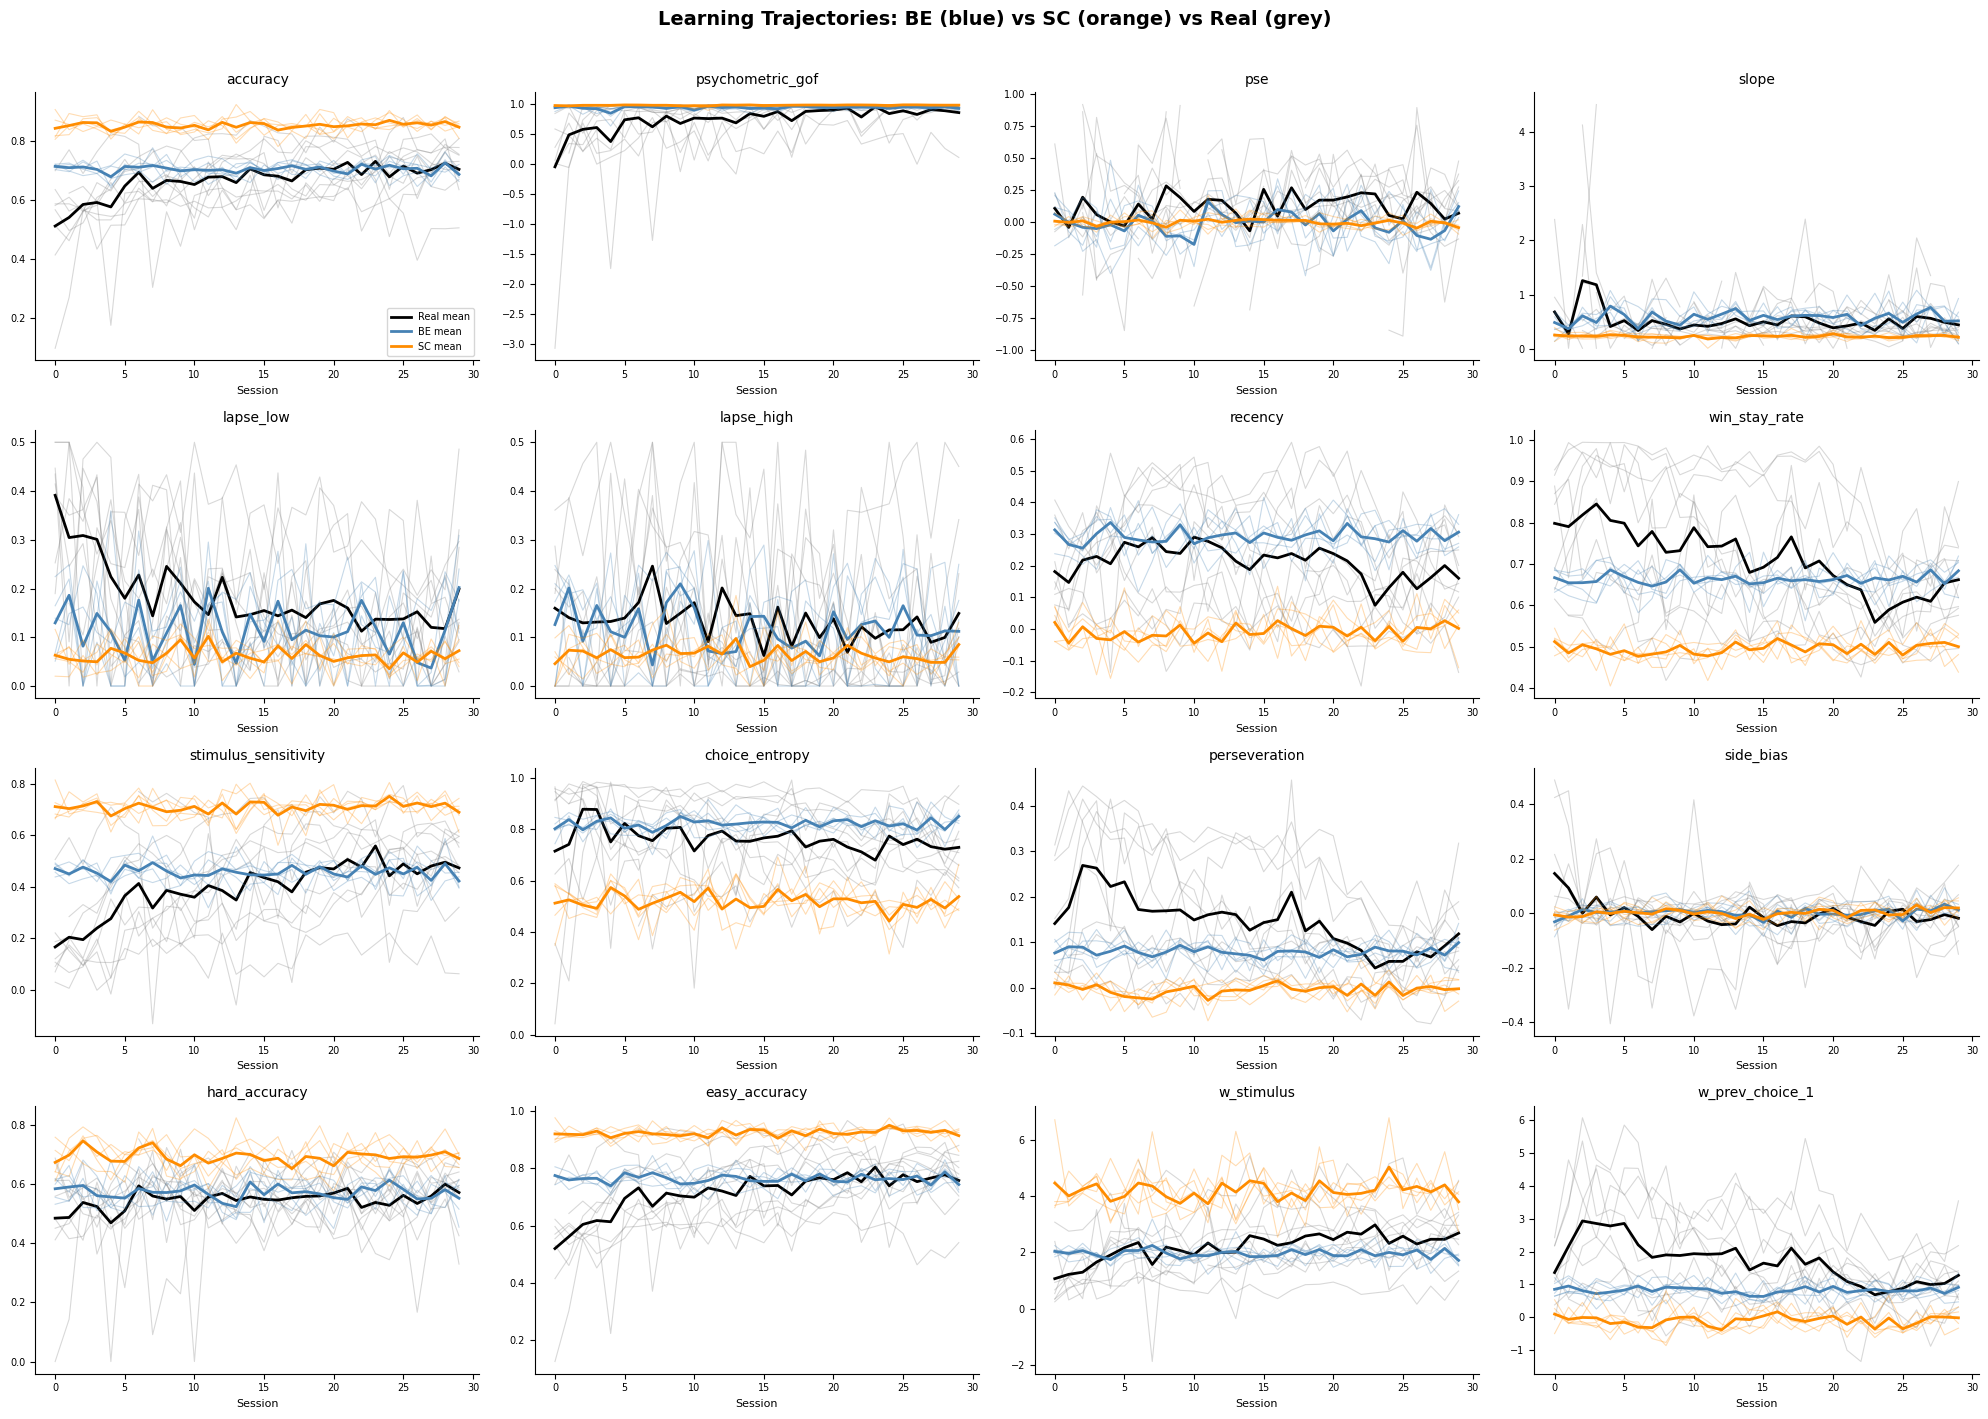

In [12]:
available = [s for s in COMPARE_STATS if s in df_be.columns and s in df_sc.columns]
if HAS_REAL:
    available = [s for s in available if s in df_real_trunc.columns]

n_stats = len(available)
n_cols = 4
n_rows = int(np.ceil(n_stats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes_flat = np.array(axes).flatten()
fig.suptitle('Learning Trajectories: BE (blue) vs SC (orange) vs Real (grey)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, sname in zip(axes_flat, available):
    # Real individual animals (grey)
    if HAS_REAL:
        for aid in df_real_trunc['animal_id'].unique():
            sub = df_real_trunc[df_real_trunc['animal_id'] == aid]
            ax.plot(sub['session_idx'], sub[sname], color='grey', alpha=0.3, lw=0.8)
        real_mean = df_real_trunc.groupby('session_idx')[sname].mean()
        ax.plot(real_mean.index, real_mean.values, 'k-', lw=2, label='Real mean')

    # BE individual animals
    for aid in df_be['animal_id'].unique():
        sub = df_be[df_be['animal_id'] == aid]
        ax.plot(sub['session_idx'], sub[sname], color='steelblue', alpha=0.3, lw=0.8)
    be_mean = df_be.groupby('session_idx')[sname].mean()
    ax.plot(be_mean.index, be_mean.values, color='steelblue', lw=2, label='BE mean')

    # SC individual animals
    for aid in df_sc['animal_id'].unique():
        sub = df_sc[df_sc['animal_id'] == aid]
        ax.plot(sub['session_idx'], sub[sname], color='darkorange', alpha=0.3, lw=0.8)
    sc_mean = df_sc.groupby('session_idx')[sname].mean()
    ax.plot(sc_mean.index, sc_mean.values, color='darkorange', lw=2, label='SC mean')

    ax.set_title(sname, fontsize=10)
    ax.set_xlabel('Session', fontsize=8)
    ax.tick_params(labelsize=7)

axes_flat[0].legend(fontsize=7)
for j in range(len(available), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Update Matrix Comparison at Matched Phases

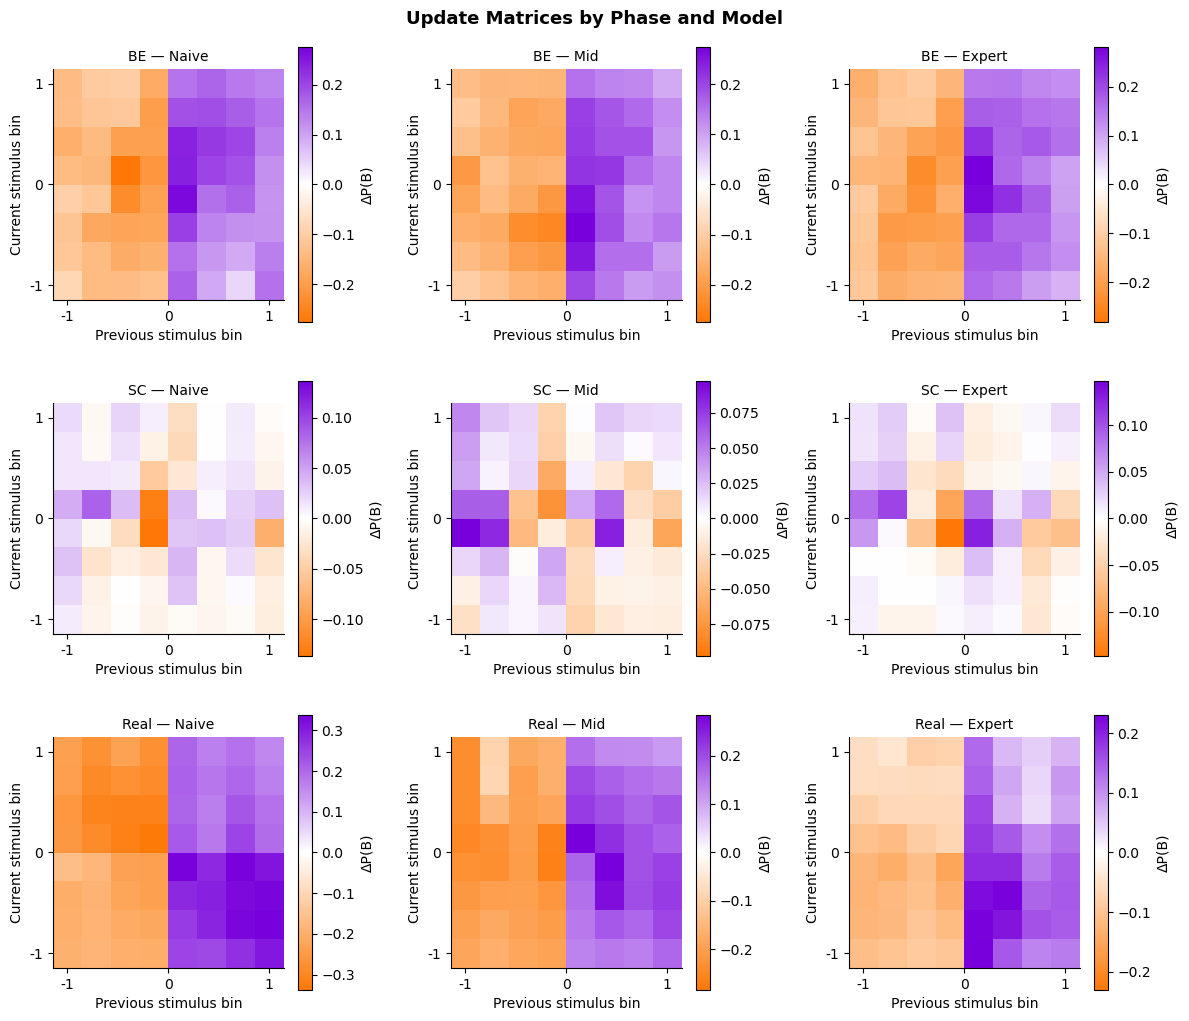

In [13]:
PHASES = {
    'Naive':  (0, 4),
    'Mid':    (10, 15),
    'Expert': (-5, None),
}

def get_phase_sessions(animal, stage, phase_range):
    sessions = animal.get_sessions(stage=stage) if stage else animal.sessions
    start, end = phase_range
    if start < 0:
        start = max(0, len(sessions) + start)
    if end is None:
        end = len(sessions)
    return sessions[start:end]


def mean_update_matrix(sessions):
    ums = []
    for sess in sessions:
        arrays = sess.trials.get_arrays(exclude_abort=True)
        um = compute_update_matrix(
            arrays['stimuli'], arrays['choices'], arrays['categories'], n_bins=8)
        um = um[0] if isinstance(um, tuple) else um  # Handle tuple output
        if um is not None and not np.all(np.isnan(um)):
            ums.append(um)
    return np.nanmean(ums, axis=0) if ums else None

# Compute for all sources
all_ums = {}
sources = [('BE', be_animals, None), ('SC', sc_animals, None)]
if HAS_REAL:
    sources.append(('Real', real_animals, STAGE))

for source_name, animals, stage in sources:
    for phase_name, phase_range in PHASES.items():
        phase_sessions = []
        for a in animals:
            phase_sessions.extend(get_phase_sessions(a, stage, phase_range))
        um = mean_update_matrix(phase_sessions) if phase_sessions else None
        all_ums[(source_name, phase_name)] = um

# Plot
n_sources = len(sources)
fig, axes = plt.subplots(n_sources, len(PHASES),
                          figsize=(4 * len(PHASES), 3.5 * n_sources))
if n_sources == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('Update Matrices by Phase and Model', fontsize=13, fontweight='bold')

for row, (source_name, _, _) in enumerate(sources):
    for col, phase_name in enumerate(PHASES):
        ax = axes[row, col]
        um = all_ums.get((source_name, phase_name))
        if um is not None:
            plot_update_matrix(um, ax=ax)
        ax.set_title(f'{source_name} — {phase_name}', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Expert-Phase Stat Distributions

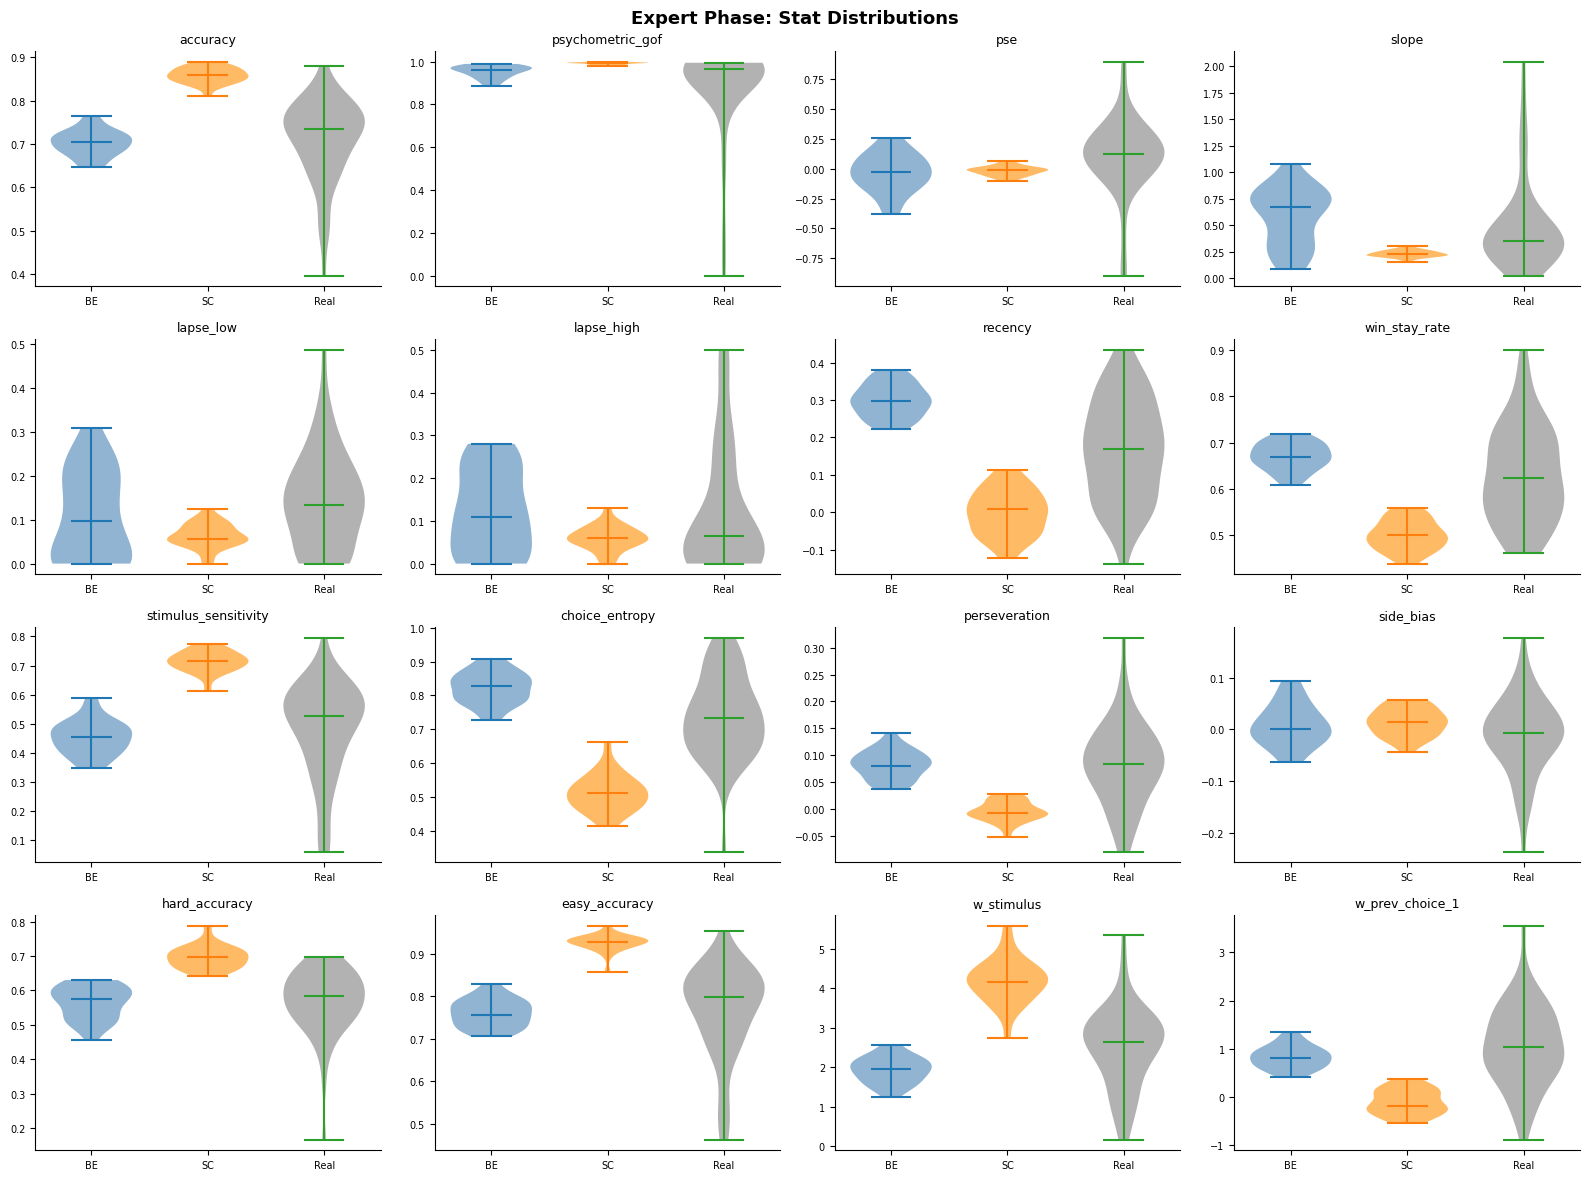

In [14]:
expert_be = df_be[df_be['session_idx'] >= N_SESSIONS_SYN - 5]
expert_sc = df_sc[df_sc['session_idx'] >= N_SESSIONS_SYN - 5]

available = [s for s in COMPARE_STATS if s in expert_be.columns and s in expert_sc.columns]
if HAS_REAL:
    expert_real = df_real_trunc[df_real_trunc['session_idx'] >= N_SESSIONS_SYN - 5]
    available = [s for s in available if s in expert_real.columns]

n_stats = len(available)
n_cols = 4
n_rows = int(np.ceil(n_stats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes_flat = np.array(axes).flatten()
fig.suptitle('Expert Phase: Stat Distributions', fontsize=13, fontweight='bold')

for ax, sname in zip(axes_flat, available):
    data_dict = {'BE': expert_be[sname].dropna(), 'SC': expert_sc[sname].dropna()}
    if HAS_REAL:
        data_dict['Real'] = expert_real[sname].dropna()

    positions = list(range(len(data_dict)))
    colours = {'BE': 'steelblue', 'SC': 'darkorange', 'Real': 'grey'}

    for pos, (label, vals) in enumerate(data_dict.items()):
        if len(vals) > 0:
            vp = ax.violinplot(vals, positions=[pos], widths=0.7, showmedians=True)
            for body in vp.get('bodies', []):
                body.set_facecolor(colours[label])
                body.set_alpha(0.6)

    ax.set_xticks(positions)
    ax.set_xticklabels(list(data_dict.keys()), fontsize=8)
    ax.set_title(sname, fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(len(available), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Post-Shift Model vs Real Comparison

Simulate both models through the full distribution shift sequence and
compare to real post-shift data. This is the core prediction test:
which model's predicted adaptation trajectory better matches the
real animals?

Uses `simulate_shift_sequence` from 0b (Section 7). If that hasn't
been run, the simulation is defined here as well.

In [15]:
from analysis.stimulus_distribution import sample_distribution
from analysis.adaptation import (
    detect_first_manipulation,
    adaptation_trajectory,
)
from behav_utils.analysis.update_matrix import compute_update_matrix_from_sessions
from behav_utils.plotting.update_matrix import plot_phase_update_matrices

In [16]:
# ── Shift sequence simulation ────────────────────────────────────────────

SHIFT_SEQUENCE = [
    ('Uniform', 30),
    ('Hard-A',  10),
    ('Hard-B',  10),
    ('Hard-A',  10),
]

def simulate_shift_sequence(
    model_type, params, shift_sequence,
    trials_per_session=TRIALS_PER_SESSION,
    burn_in=BURN_IN, seed=42, n_bins=8,
):
    """Simulate model through multi-phase distribution shift."""
    rng = np.random.default_rng(seed)

    if model_type == 'BE':
        state = BEModel.create_initial_state(
            burn_in=burn_in, params=params, seed=seed)
    else:
        state = SCModel.create_initial_state(
            params=params, burn_in=burn_in, seed=seed)

    results = []
    session_idx = 0

    for distribution, n_sessions in shift_sequence:
        for s in range(n_sessions):
            stimuli, categories = sample_distribution(
                trials_per_session, distribution, rng=rng)

            if model_type == 'BE':
                choices, p_B, state, _ = BEModel.simulate_session(
                    params, state, stimuli, categories, rng)
            else:
                choices, p_B, state, _ = SCModel.simulate_session(
                    params, state, stimuli, categories, rng)

            valid = ~np.isnan(choices)
            stats = compute_summary_stats(
                choices[valid], stimuli[valid], categories[valid],
                stat_names=['accuracy', 'psychometric', 'recency',
                            'stimulus_recency', 'win_stay', 'side_bias'],
                return_dict=True,
            )
            flat = {}
            for k, v in stats.items():
                if isinstance(v, dict):
                    flat.update(v)
                elif not isinstance(v, np.ndarray):
                    flat[k] = v

            results.append({
                'session_idx': session_idx,
                'distribution': distribution,
                **flat,
            })
            session_idx += 1

    return pd.DataFrame(results)


# ── Representative parameters (same as 0b) ────────────────────────────────
BE_SHIFT_PARAMS = BEParams(
    sigma_percep=0.15, A_repulsion=0.10,
    eta_learning=0.35, eta_relax=0.12,
)
SC_SHIFT_PARAMS = SCParams(
    sigma_percep=0.15, A_repulsion=0.10,
    gamma=0.95, sigma_update=0.30,
)

be_shift = simulate_shift_sequence('BE', BE_SHIFT_PARAMS, SHIFT_SEQUENCE)
sc_shift = simulate_shift_sequence('SC', SC_SHIFT_PARAMS, SHIFT_SEQUENCE)
print(f'Simulated: BE {len(be_shift)} sessions, SC {len(sc_shift)} sessions')

Simulated: BE 60 sessions, SC 60 sessions


### 7.1 Load Real Post-Shift Data

In [17]:
# Load real data and find animals with shifts
real_shift_data = {}  # aid -> {trajectory df, shift_detail}

if 'experiment' not in dir():
    try:
        experiment = load_experiment(CONFIG_PATH)
    except Exception as e:
        print(f'Could not load real data: {e}')
        experiment = None

if experiment is not None:
    for aid in experiment.animal_ids:
        animal = experiment.get_animal(aid)
        manip = detect_first_manipulation(animal, stage=STAGE)
        if manip:
            all_sess = animal.get_sessions(stage=STAGE)
            shift_idx = manip['session_idx']
            baseline = all_sess[:shift_idx]
            post = all_sess[shift_idx:]

            if len(baseline) >= 5 and len(post) >= 3:
                traj = adaptation_trajectory(
                    baseline, post,
                    stats=['accuracy', 'pse', 'slope', 'recency',
                           'stimulus_recency', 'win_stay', 'side_bias'],
                )
                real_shift_data[aid] = {
                    'trajectory': traj,
                    'detail': manip['details'],
                    'baseline': baseline,
                    'post': post,
                }

    print(f'{len(real_shift_data)} animals with shift data')
else:
    print('No real data available — showing model predictions only')

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


9 animals with shift data


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


### 7.2 Overlay: Model Predictions vs Real Trajectories

Model trajectories aligned to the first shift (session 30 in simulation)
overlaid with real data aligned to their actual shift point.

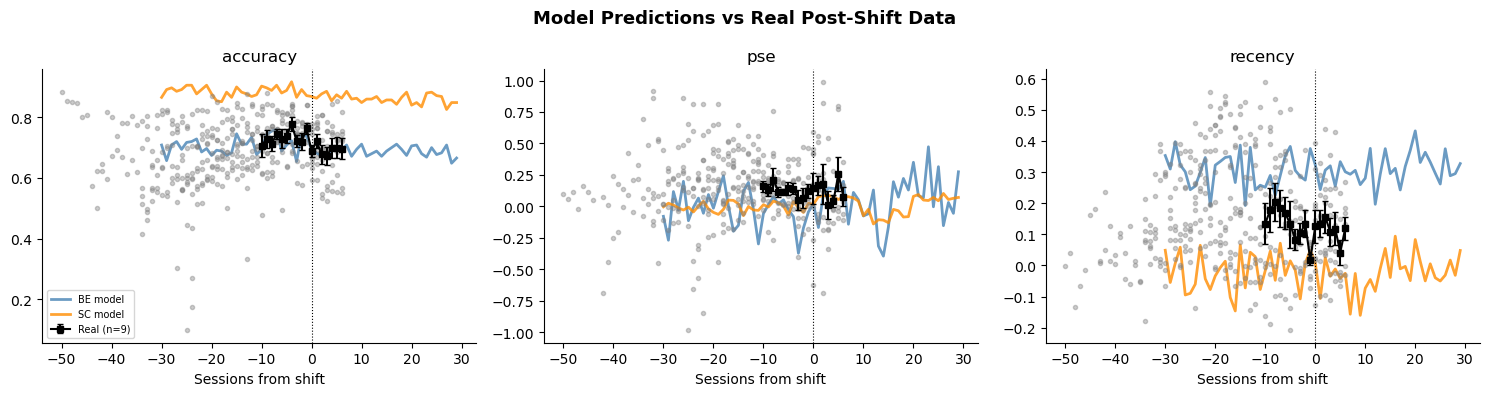

In [18]:
OVERLAY_STATS = ['accuracy', 'pse', 'recency']
SHIFT_SESSION = 30  # where the first shift occurs in simulation

fig, axes = plt.subplots(1, len(OVERLAY_STATS),
                          figsize=(5 * len(OVERLAY_STATS), 4))

for col, stat in enumerate(OVERLAY_STATS):
    ax = axes[col]

    # Model predictions (aligned: session 30 = shift point = 0)
    for model_df, color, label in [
        (be_shift, 'steelblue', 'BE model'),
        (sc_shift, 'darkorange', 'SC model'),
    ]:
        if stat in model_df.columns:
            x = model_df['session_idx'] - SHIFT_SESSION
            ax.plot(x, model_df[stat], '-', color=color, lw=2,
                    label=label, alpha=0.8)

    # Real data overlay
    for aid, rdata in real_shift_data.items():
        traj = rdata['trajectory']
        if stat in traj.columns:
            ax.plot(traj['relative_session'], traj[stat],
                    'o', ms=3, color='grey', alpha=0.4)

    # Real data mean ± SEM (if multiple animals)
    if len(real_shift_data) > 1:
        all_trajs = [r['trajectory'] for r in real_shift_data.values()]
        from analysis.adaptation import aggregate_trajectories
        agg = aggregate_trajectories(
            all_trajs, stats=[stat], session_range=(-10, 15),
        )
        stat_agg = agg[agg['stat'] == stat].sort_values('relative_session')
        if not stat_agg.empty:
            ax.errorbar(
                stat_agg['relative_session'], stat_agg['mean'],
                yerr=stat_agg['sem'], fmt='s-', ms=4, color='black',
                capsize=2, lw=1.5, label=f'Real (n={len(real_shift_data)})',
            )

    ax.axvline(0, color='black', ls=':', lw=0.8)
    ax.set_xlabel('Sessions from shift')
    ax.set_title(stat)
    if col == 0:
        ax.legend(fontsize=7)

fig.suptitle('Model Predictions vs Real Post-Shift Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Quantitative comparison

Quantitative model–data scoring (MSE per stat, UM comparison) requires
validated model assignments from notebooks 3a/3c. Once those are available,
the comparison can assess whether the winning model's predicted adaptation
trajectory matches the real data better than the losing model's.

### Summary

Sections 2–6 compare synthetic BE and SC trajectories with real data
at a qualitative level. Section 7 overlays model-predicted post-shift
trajectories on real adaptation data where available.

Quantitative model–data scoring requires model assignments from 3a/3c.